In [36]:
#import imported libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


retail = pd.read_excel(r'D:\projects\Retail_data\online_retail.xlsx')


In [37]:
#Make a copy of original dataset
retail_clean = retail.copy()

#Inspect data using shape and head
print(retail_clean.shape)
print(retail_clean.head(5))

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


#  Data cleaning 

In [38]:
#Check missing values 

print(retail_clean.isnull().sum())

#Check duplicate rows
print(retail_clean.duplicated().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
6865


In [39]:
#Drop missing descriptions
retail_clean = retail_clean.dropna(subset=['Description'])

In [40]:
#Drop missing customer Id
retail_clean = retail_clean.dropna(subset = ['Customer ID'])

In [41]:
#Remove negative quantity & price
retail_clean = retail_clean[(retail_clean['Quantity'] > 0) & (retail_clean['Price'] > 0)]

In [42]:
#Classify StockCode into Product, Voucher and Non-Product categories
def classify_stockcode(code):
    if pd.isna(code):
        return 'Unknown'
        
    
    code = str(code).strip().upper()  # normalize everything

    if code in ['POST', 'M', 'DOT', 'S', 'PADS']:
        return 'Non-Product'
    elif 'GIFT' in code:
        return 'Voucher'
    else:
        return 'Product'

retail_clean['StockType'] = retail_clean['StockCode'].apply(classify_stockcode)

In [43]:
#Convert StockType column to categorical data type
retail_clean['StockType'] = retail_clean['StockType'].astype('category')

In [44]:
#Remove duplicate transactions
retail_clean = retail_clean.drop_duplicates()

# Feature Engineering

In [45]:
#Convert InvoiceDate to datetime
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])  #dtype('<M8[ns]')

In [46]:
#Create Total Amount
retail_clean['TotalAmount'] = retail_clean['Quantity'] * retail_clean['Price']

In [47]:
#Extract time features (Month & Year)
retail_clean['Year'] = retail_clean['InvoiceDate'].dt.year
retail_clean['Month'] = retail_clean['InvoiceDate'].dt.month

In [48]:
print(retail_clean.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country StockType  \
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom   Product   
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom   Product   
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom   Product   
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom   Product   
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom   Product   

   TotalAmount  Year  Month  
0         83.4  2009     12  
1         81.0  2009     12  
2         81.0  2009     12  
3        100.8  2009     12  
4 

# RFM Analysis

In [49]:
#Find latest date
latest_date = retail_clean['InvoiceDate'].max()

print(latest_date)

2010-12-09 20:01:00


In [50]:
#Create Snapshot Date
snapshot_date = latest_date + pd.Timedelta(days = 1)

print(snapshot_date)

2010-12-10 20:01:00


In [51]:
#Create RFM table
rfm = retail_clean.groupby('Customer ID').agg({

    'InvoiceDate':        #Recency
        lambda x: (snapshot_date - x.max()).days,

    'Invoice': 'nunique', #Frequency

    'TotalAmount': 'sum'  #Monetary

})

print(rfm)

             InvoiceDate  Invoice  TotalAmount
Customer ID                                   
12346.0              165       11       372.86
12347.0                3        2      1323.32
12348.0               74        1       222.16
12349.0               43        3      2671.14
12351.0               11        1       300.93
...                  ...      ...          ...
18283.0               18        6       619.37
18284.0               67        1       461.68
18285.0              296        1       427.00
18286.0              112        2      1296.43
18287.0               18        4      2345.71

[4312 rows x 3 columns]


In [52]:
#Rename the columns name
rfm.columns =['Recency', 'Frequency', 'Monetary']

print(rfm)

             Recency  Frequency  Monetary
Customer ID                              
12346.0          165         11    372.86
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          3   2671.14
12351.0           11          1    300.93
...              ...        ...       ...
18283.0           18          6    619.37
18284.0           67          1    461.68
18285.0          296          1    427.00
18286.0          112          2   1296.43
18287.0           18          4   2345.71

[4312 rows x 3 columns]


In [53]:
#RFM Statistics
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


# Feature Scaling

In [54]:
# Feature Scaling using StandardScaler (to normalize RFM data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow Method

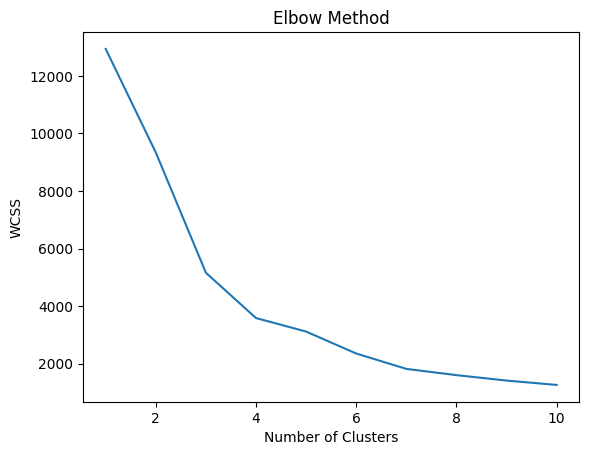

In [55]:
#Find best number of clusters (Elbow Method)   #tells us how many groups we should create

#Import libraries
from sklearn.cluster import KMeans


wcss = []     #Create empty list to store results
             #Within Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)   #Create KMeans model
    kmeans.fit(rfm_scaled)   #Train model
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# K-Means Clustering

In [56]:
#Apply K-means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [57]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,1
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0


In [58]:
#cluster averages
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


# Customer Segmentation

In [60]:
#Cluster names
def label_cluster(cluster):
    if cluster == 1:
        return 'At Risk'
    elif cluster == 0:
        return 'Regular'
    elif cluster == 2:
        return 'VIP'
    elif cluster == 3:
        return 'Champions'

rfm['Segment'] = rfm['Cluster'].apply(label_cluster)


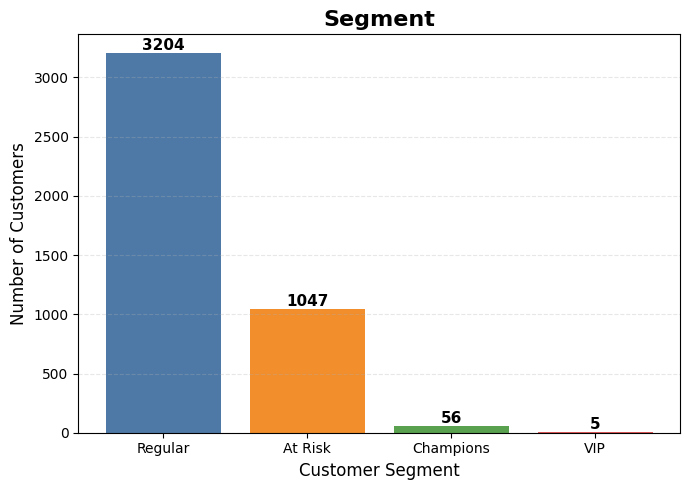

In [61]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = rfm['Segment'].value_counts()

# Create figure
plt.figure(figsize=(7, 5))

# Create bars with different colors
bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
)

# Title and labels
plt.title('Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Improve layout
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
#Revenue contribution by segment
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

In [ ]:
#Percentage of customers in each segment
(rfm['Segment'].value_counts(normalize=True) * 100).round(2)